In [1]:
# --- repo-root prelude (added 2026-08-02 with the folder reorganisation) ---
# This notebook lives in a subfolder but every path below is relative to the REPO ROOT,
# and `import features` needs the root on sys.path. Walk up until we find paths.py, so it
# works whether Jupyter was started here or at the root. Idempotent.
import os, sys
while not os.path.exists('paths.py') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import paths  # noqa: F401  - also puts pipeline/ + models/ on sys.path
# --- end prelude ---


# Margin model — predicting HOW MUCH a candidate wins by

**Completely separate from `model.ipynb`** (the win/lose classifier): separate notebook,
separate tuned hyperparameters, separate saved artifact (`data/margin_model_xgb.json`).

**Why this model exists:** for win/lose, the poll leader is already right ~87% of the time —
polls are the ceiling. But polls do NOT already contain *how far off they themselves will be*.
Predicting the actual victory margin is where fundamentals (incumbency, prior results,
national environment, economy) get a fair test.

**Target:** `margin_actual` = candidate's actual vote % minus the best opponent's actual
vote % (positive = won by that much). Same leak-free features from `features.py`; the
`vote_pct` label is used ONLY as the target, never as a feature.

**Validation:** identical nested scheme to the win model — tune on 1998–2016, honest
leave-one-cycle-out evaluation on 2018–2024.

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from cycles import CYCLES, TUNE_CYCLES, EVAL_CYCLES, natl_env
import features as F
from macro_features import build_macro

pd.set_option('display.max_columns', 60)
print('xgboost', xgb.__version__)

xgboost 3.2.0


In [3]:
d = pd.read_csv('polls_long_with_results.csv', low_memory=False)
# DEAD MATCHUPS - same filter model.ipynb applies (added 2026-08-06). A question whose
# opponent never made the ballot measured the surviving candidate against someone who
# never ran; keep the two notebooks in step or their poll sets silently diverge.
_gen = d[d['stage'] == 'general']
_q = _gen.groupby(['race_id', 'question_id'])['has_result'].agg(['sum', 'size'])
_dead = set(_q[(_q['sum'] > 0) & (_q['sum'] < _q['size'])].index)
_key = list(zip(d['race_id'], d['question_id']))
_drop = pd.Series([k in _dead for k in _key], index=d.index) & (d['stage'] == 'general')
print(f'dead-matchup rows dropped from training: {int(_drop.sum())} ({len(_dead)} questions)')
d = d[~_drop]
d = d[d['has_result'] == 1].copy()
d = F.prepare_polls(d)
d = d[d['year'].isin(CYCLES)].copy()
d['race_id'] = (d['year'].astype(str) + '_' + d['state'] + '_' + d['office']
                + d['district'].radd('-').where(d['district'] != '', ''))


dead-matchup rows dropped from training: 1522 (646 questions)


In [4]:
FUNDS = F.load_fundamentals()
NATL_ENV = natl_env()
FEC = F.load_fec(extended=True)
BIAS = F.compute_bias_priors(d)
PRIMRES = F.load_primary_results()
macro = build_macro()
MACRO_FEATS = sorted({k for cyc in macro for k in macro[cyc]})
# bio_office_level SHIPPED 2026-07-29 (margin MAE -0.071 on 100%-covered leak-free data) - see
# the win model's BASE-build cell for the full flip-the-verdict story. Pass candidate_bios=True
# here AND to build_candidate_table below AND at serve time (predict_margin.py).
FEATURES = F.feature_list(MACRO_FEATS, fund=True, candidate_bios=True,
                           primary_results=True)
print('features:', len(FEATURES), '| macro:', len(MACRO_FEATS))

features: 190 | macro: 144


In [5]:
# candidate table + leak-free folds (same construction as the win model)
BIOS = F.load_candidate_bios()
BASE = F.build_candidate_table(d, macro, NATL_ENV, FUNDS, house_train_years=CYCLES, fec=FEC,
                               bias_priors=BIAS, candidate_bios=BIOS,
                               primary_results=PRIMRES)

def add_margin_target(c):
    # best OTHER = the strongest opponent in the whole RESULTS field (best_other_pct, from
    # src/results_labels.py), not among the POLLED candidates (2026-09-25). The polled subset
    # often omits the real winner - 538's pre-2018 file is top-two only, so Angus King (ME-Gov
    # 1998, 59%) is absent and Longley's target read +6.9 over Connolly instead of -40 behind
    # King. Same design the primary margin model already uses.
    c = c.copy()
    c['margin_actual'] = c['vote_pct'] - c['best_other_pct']
    return c[c['margin_actual'].notna()]

def fold_table(test_year):
    house = F.compute_house_effect(d, [y for y in CYCLES if y != test_year])
    adj = F.candidate_poll_adj(d, house).rename('poll_adj').reset_index()
    c = BASE.drop(columns='poll_adj').merge(adj, on=['race_id', 'cand_key'], how='left')
    return add_margin_target(c)

FOLDS = {ty: fold_table(ty) for ty in CYCLES}
cand = FOLDS[2024]

# sanity: sign of actual margin must almost always agree with the win label
agree = ((cand['margin_actual'] > 0).astype(int) == cand['won']).mean()
print('candidate rows with margin target:', len(cand))
print('sign(margin) agrees with won:', round(agree, 4))
print('bio_office_level coverage:', round(cand['bio_office_level'].notna().mean(), 3))
# Residual disagreement is RCV races (ME/AK), where the first-round leader can lose; the
# target is first-round share by design. It was ~3.5% until 2026-09-25 - most of that was
# the fusion-line / mixed-round label bug (results_labels.py), not RCV. Now ~0.1%.
assert agree > 0.99, 'margin target inconsistent with win labels'
print('margin distribution:', cand['margin_actual'].describe().round(1).to_dict())

candidate rows with margin target: 4406
sign(margin) agrees with won: 0.9995
bio_office_level coverage: 0.998
margin distribution: {'count': 4406.0, 'mean': -5.9, 'std': 25.1, 'min': -76.9, '25%': -18.0, '50%': -2.6, '75%': 10.0, 'max': 76.9}


In [6]:
# ---- nested tuning: XGBRegressor, scored by MAE over the 1998-2016 cycles ----
import itertools, random

def cv_mae(params, test_cycles):
    maes = []
    for ty in test_cycles:
        c = FOLDS[ty]
        tr = c[c['year'] != ty]; te = c[c['year'] == ty]
        m = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **params)
        m.fit(tr[FEATURES], tr['margin_actual'])
        maes.append(mean_absolute_error(te['margin_actual'], m.predict(te[FEATURES])))
    return float(np.mean(maes))

GRID = dict(max_depth=[2, 3], learning_rate=[0.02, 0.03, 0.05],
            n_estimators=[200, 400], min_child_weight=[8, 15, 30],
            subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.4, 0.6, 1.0],
            reg_lambda=[1, 5, 20], reg_alpha=[0, 1])
keys = list(GRID)
combos = list(itertools.product(*[GRID[k] for k in keys]))
random.seed(0); random.shuffle(combos); combos = combos[:120]

best = None
for combo in combos:
    p = dict(zip(keys, combo))
    mae = cv_mae(p, TUNE_CYCLES)
    if best is None or mae < best[0]:
        best = (mae, p)

XGBR_PARAMS = dict(best[1], objective='reg:squarederror', random_state=42)
print(f'best TUNE-cycle MAE (1998-2016): {best[0]:.3f} pts')
print('XGBR_PARAMS =', best[1])

best TUNE-cycle MAE (1998-2016): 5.718 pts
XGBR_PARAMS = {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 400, 'min_child_weight': 8, 'subsample': 0.6, 'colsample_bytree': 1.0, 'reg_lambda': 20, 'reg_alpha': 0}


In [7]:
# ---- PRIMARY HONEST EVAL - EXPANDING-WINDOW on 2018-2024: each fold trains strictly
# on cycles BEFORE the test cycle (true prospective; tuner never saw these cycles).
# NOTE the 2018 fold only has 10 training cycles and is the weak one (MAE ~10 vs ~6
# later) - the 2026-relevant fold is 2024 (13 cycles), where expanding == LOCO.
# Baselines retrain per-fold on the same expanding window (apples-to-apples). ----
# Baselines:
#   raw poll margin      : predicted margin = avg_margin_over_time (the polls' own answer)
#   calibrated poll marg : linear fit  margin_actual ~ avg_margin_over_time  on train cycles
rows, preds = [], {}
for ty in EVAL_CYCLES:
    c = FOLDS[ty]
    tr = c[c['year'] < ty]; te = c[c['year'] == ty].copy()

    m = xgb.XGBRegressor(**XGBR_PARAMS)
    m.fit(tr[FEATURES], tr['margin_actual'])
    te['pred_model'] = m.predict(te[FEATURES])

    te['pred_poll'] = te['avg_margin_over_time']
    fit_tr = tr.dropna(subset=['avg_margin_over_time'])
    lin = LinearRegression().fit(fit_tr[['avg_margin_over_time']], fit_tr['margin_actual'])
    x = te[['avg_margin_over_time']].fillna(0.0)
    te['pred_lin'] = lin.predict(x)

    def acc(col):
        pick = te.loc[te.groupby('race_id')[col].idxmax()]
        return pick['won'].mean()
    rows.append(dict(
        cycle=ty, n=len(te),
        MAE_model=mean_absolute_error(te['margin_actual'], te['pred_model']),
        MAE_poll=mean_absolute_error(te.dropna(subset=['pred_poll'])['margin_actual'],
                                     te['pred_poll'].dropna()),
        MAE_lin=mean_absolute_error(te['margin_actual'], te['pred_lin']),
        R2_model=r2_score(te['margin_actual'], te['pred_model']),
        acc_model=acc('pred_model'), acc_poll=acc('poll_avg'),
    ))
    preds[ty] = te

ev = pd.DataFrame(rows).set_index('cycle')
print('=== PRIMARY honest margin eval (EXPANDING-WINDOW 2018-2024), margins in percentage points ===')
print(ev.round(3).to_string())
print('\nMEAN:')
print(ev.mean().round(3).to_string())
print('\nMAE_model < MAE_lin < MAE_poll would mean features add real margin signal')

=== PRIMARY honest margin eval (EXPANDING-WINDOW 2018-2024), margins in percentage points ===
         n  MAE_model  MAE_poll  MAE_lin  R2_model  acc_model  acc_poll
cycle                                                                  
2018   633      5.228     6.670    6.976     0.941      0.885     0.885
2020   389      5.359     6.979    6.639     0.945      0.845     0.838
2022   475      4.463     6.678    5.984     0.956      0.879     0.879
2024   339      4.456     5.711    5.265     0.959      0.902     0.879

MEAN:
n            459.000
MAE_model      4.876
MAE_poll       6.509
MAE_lin        6.216
R2_model       0.950
acc_model      0.878
acc_poll       0.870

MAE_model < MAE_lin < MAE_poll would mean features add real margin signal


In [8]:
# COMPANION eval - LOCO (train on all other cycles INCLUDING FUTURE ones): kept only
# to monitor the optimism gap vs the primary expanding-window eval above. Measured
# 2026-07-14: gap = 1.0 MAE pt, entirely from the 2018 fold (10 train cycles);
# 2020/2022/2024 converge.
ew_rows = []
for ty in EVAL_CYCLES:
    c = FOLDS[ty]
    tr = c[c['year'] != ty]; te = c[c['year'] == ty].copy()
    m = xgb.XGBRegressor(**XGBR_PARAMS)
    m.fit(tr[FEATURES], tr['margin_actual'])
    te['pred_loco'] = m.predict(te[FEATURES])
    pick = te.loc[te.groupby('race_id')['pred_loco'].idxmax()]
    ew_rows.append(dict(
        cycle=ty, n_train_cycles=tr['year'].nunique(),
        MAE=mean_absolute_error(te['margin_actual'], te['pred_loco']),
        R2=r2_score(te['margin_actual'], te['pred_loco']),
        race_acc=pick['won'].mean(),
    ))
loco = pd.DataFrame(ew_rows).set_index('cycle')
print('=== companion eval: LOCO (trains on future cycles; headline is the expanding-window table above) ===')
print(loco.round(3).to_string())
print()
print('LOCO MAE:', round(loco['MAE'].mean(), 3),
      '| PRIMARY expanding-window MAE:', round(ev['MAE_model'].mean(), 3),
      '| LOCO optimism:', round(ev['MAE_model'].mean() - loco['MAE'].mean(), 3), 'pts (driven by the 2018 fold)')


=== companion eval: LOCO (trains on future cycles; headline is the expanding-window table above) ===
       n_train_cycles    MAE     R2  race_acc
cycle                                        
2018               13  4.887  0.946     0.868
2020               13  5.229  0.949     0.845
2022               13  4.283  0.959     0.884
2024               13  4.456  0.959     0.902

LOCO MAE: 4.714 | PRIMARY expanding-window MAE: 4.876 | LOCO optimism: 0.162 pts (driven by the 2018 fold)


In [9]:
# where does the margin model win/lose vs the calibrated poll baseline?
allp = pd.concat(preds.values())
allp['err_model'] = (allp['pred_model'] - allp['margin_actual']).abs()
allp['err_lin']   = (allp['pred_lin']   - allp['margin_actual']).abs()
by_office = allp.groupby('office')[['err_model', 'err_lin']].mean().round(2)
print('MAE by office (model vs calibrated poll):')
print(by_office.to_string())
close = allp[allp['abs_gap'] < 5]
print('\nclose races only (polled gap < 5):')
print(close[['err_model', 'err_lin']].mean().round(2).to_string())

MAE by office (model vs calibrated poll):
          err_model  err_lin
office                      
Governor       4.49     6.69
House          5.22     6.46
Senate         4.46     5.72

close races only (polled gap < 5):
err_model    4.34
err_lin      5.71


wrote models/poll/margin_feature_importance.csv


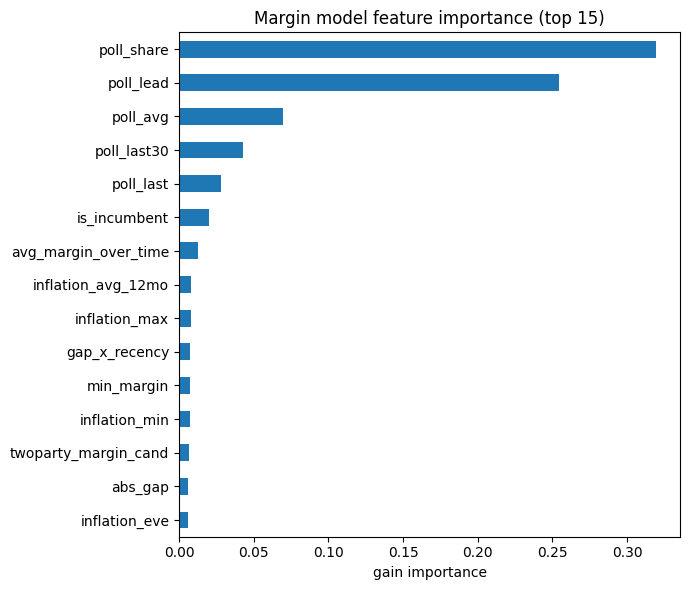

poll_share              0.3194
poll_lead               0.2545
poll_avg                0.0697
poll_last30             0.0426
poll_last               0.0279
is_incumbent            0.0199
avg_margin_over_time    0.0126
inflation_avg_12mo      0.0078
inflation_max           0.0077
gap_x_recency           0.0074
min_margin              0.0072
inflation_min           0.0071
twoparty_margin_cand    0.0068
abs_gap                 0.0062
inflation_eve           0.0057
dtype: float32

In [10]:
m_all = xgb.XGBRegressor(**XGBR_PARAMS)
train_all = add_margin_target(BASE)
m_all.fit(train_all[FEATURES], train_all['margin_actual'])

imp = pd.Series(m_all.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp_df = imp.rename('gain_importance').reset_index().rename(columns={'index': 'feature'})
imp_df['rank'] = range(1, len(imp_df) + 1)
imp_df.to_csv('models/poll/margin_feature_importance.csv', index=False)  # beside the model (2026-08-02)
print('wrote models/poll/margin_feature_importance.csv')

top15 = imp.head(15).sort_values()
ax = top15.plot.barh(figsize=(7, 6), title='Margin model feature importance (top 15)')
ax.set_xlabel('gain importance')
plt.tight_layout(); plt.show()
imp.head(15).round(4)

In [11]:
# ---- PRODUCTION artifact (separate from the win model's) ----
import json
m_all.save_model('data/margin_model_xgb.json')
with open('data/margin_model_features.json', 'w') as f:
    json.dump({'features': FEATURES, 'macro_feats': MACRO_FEATS,
               'target': 'margin_actual (own vote_pct minus best opponent, pct points)',
               'trained_on_cycles': sorted(train_all['year'].unique().tolist()),
               'xgb_params': {k: v for k, v in XGBR_PARAMS.items()}}, f, indent=1)
print('saved data/margin_model_xgb.json + data/margin_model_features.json',
      f'({len(train_all)} rows, {train_all["race_id"].nunique()} races)')

saved data/margin_model_xgb.json + data/margin_model_features.json (4406 rows, 1965 races)


## Notes

- The interesting comparison is **MAE_model vs MAE_lin**: the linear baseline already fixes
  any constant bias/scale in the polled margin, so beating it means the *other* features
  (incumbency, prior margin, national environment, economy) carry real margin information.
- `acc_model` vs `acc_poll` shows whether better margins also flip winner calls.
- **Never** feed `vote_pct` / `margin_actual` / `race_winning_pct` as features — they are
  the outcome. The label flows through `features.py` as a passenger column only.
- Prediction on live races: `predict_margin.py` (same polling-agg feed as `predict.py`).